In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import pathlib
from scipy.io import wavfile
import concurrent.futures
from tqdm import tqdm
import tensorflow as tf
import librosa
from tensorflow import keras
import IPython.display as ipd
from sklearn.preprocessing import MinMaxScaler,LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay,classification_report

### 1. Loading the Dataset

In [37]:
def load_dataset(path,targets):
    dataset_path=pathlib.Path(path)
    dataset=[]
    for folder in dataset_path.iterdir():
        if folder.name not in targets:
            label="unknown"
        else:
            label=folder.name
        aud_files=list(folder.glob("*.wav"))
        for file in aud_files:
            dataset.append({
                "file_path":str(file),
                "label":label,
                "word":folder.name
            })
    df=pd.DataFrame(dataset)
    return df

In [38]:
target_words=["on","off"]
dataset_direc=r"C:\Users\sambi\OneDrive\Desktop\Python\DL\TinyML_key_detection\audio_dataset_mix"
df_dataset=load_dataset(dataset_direc,target_words)

In [39]:
print(df_dataset['label'].value_counts())

label
unknown    59997
on          2447
off         2437
Name: count, dtype: int64


In [40]:
df_dataset.head()

,file_path,label,word
0,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,bed
1,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,bed
2,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,bed
3,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,bed
4,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,bed


### 2. Audio Preprocessing

In [180]:
ipd.Audio(df_dataset[df_dataset["label"]=="off"]["file_path"].iloc[-80])

In [52]:
def conv_path_to_mfcc(x):
    sr,y=wavfile.read(x)
    y=y.astype(np.float32) / np.iinfo(np.int16).max
    TARGET_SAMPLES = 16000
    if len(y)<TARGET_SAMPLES:
        padding=TARGET_SAMPLES-len(y)
        y=np.pad(y,(0,padding),"constant")
    elif len(y)>TARGET_SAMPLES:
        y=y[:TARGET_SAMPLES]
    mfcc=librosa.feature.mfcc(y=y,n_mfcc=13,sr=sr)
    return mfcc

In [57]:
df=df_dataset.copy()
with concurrent.futures.ThreadPoolExecutor() as executor:
    df['mfcc']=tqdm(executor.map(conv_path_to_mfcc, df['file_path']), total=len(df['file_path']))
df.head()

100%|██████████| 64881/64881 [14:22<00:00, 75.23it/s] 


,file_path,label,word,mfcc
0,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,bed,"[[-568.9026, -562.6796, -560.2992, -558.3506, ..."
1,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,bed,"[[-505.0474, -486.37302, -482.7918, -488.18475..."
2,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,bed,"[[-491.76334, -472.9499, -475.30588, -476.9876..."
3,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,bed,"[[-635.1825, -605.6889, -602.42395, -594.3518,..."
4,C:\Users\sambi\OneDrive\Desktop\Python\DL\Tiny...,unknown,bed,"[[-635.22125, -603.7008, -602.8691, -601.9138,..."


In [220]:
x=np.stack(df['mfcc'])
le=LabelEncoder()
y=le.fit_transform(df['label'])


In [221]:
x.shape

(64881, 13, 32)

In [222]:
c=0
for i in range(len(x)):
    if x[i].shape[1]!=32:
        c+=1
c

0

In [223]:
original_shape=x.shape
x_flattened=x.reshape(x.shape[0], -1)
scaler=MinMaxScaler()
x_scaled_flattened=scaler.fit_transform(x_flattened)
x_scaled=x_scaled_flattened.reshape(original_shape)
x_scaled=x_scaled.reshape(-1,13,32,1)
x_scaled.shape

(64881, 13, 32, 1)

In [224]:
df0=df[df['label']=='on']
df1=df[df['label']=='off']
df2=df[df['label']=='unknown']
df0.shape,df1.shape,df2.shape

((2447, 4), (2437, 4), (59997, 4))

In [225]:
df2_new=df2.sample(2450)
df2_new.shape

(2450, 4)

In [226]:
df_new=pd.concat([df0,df1,df2_new],axis='index')
x_new=np.stack(df_new['mfcc'])
original_shape_new=x_new.shape
x_new_flattened=x_new.reshape(x_new.shape[0], -1)
new_scaler=MinMaxScaler()
x_new_scaled_flattened=scaler.transform(x_new_flattened)
x_new_scaled=x_new_scaled_flattened.reshape(original_shape_new)
x_new_scaled=x_new_scaled.reshape(-1,13,32,1)
x_new_scaled.shape

(7334, 13, 32, 1)

In [227]:
y_new=le.transform(df_new['label'])

### 3. Splitting the Dataset into Training and Test Dataset

In [228]:
# x_train,x_test,y_train,y_test=train_test_split(x_scaled,y,test_size=0.2,stratify=y,random_state=0)
x_train,x_test,y_train,y_test=train_test_split(x_new_scaled,y_new,test_size=0.2,stratify=y_new,random_state=0)

### 4. Model Building 

In [229]:
model=keras.Sequential([
    keras.layers.Input(shape=(13,32,1)),
    keras.layers.Conv2D(filters=32,kernel_size=(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(filters=64,kernel_size=(3,3),activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Flatten(),
    keras.layers.Dense(128,activation='relu'),
    keras.layers.Dropout(0.5,seed=0),
    keras.layers.Dense(64,activation='relu'),
    keras.layers.Dropout(0.5,seed=0),
    keras.layers.Dense(3,activation='softmax')
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train,y_train,epochs=10)

Epoch 1/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.3463 - loss: 1.0982
Epoch 2/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5326 - loss: 0.9354
Epoch 3/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6252 - loss: 0.8135
Epoch 4/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6886 - loss: 0.7327
Epoch 5/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7205 - loss: 0.6798
Epoch 6/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7593 - loss: 0.6204
Epoch 7/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7866 - loss: 0.5592
Epoch 8/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8069 - loss: 0.5153
Epoch 9/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8250 - loss: 0.4727
Epoch 10/10
184/184 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8355 - loss: 0.4415


### 5. Model Evaluation and Classification Report

In [230]:
model.evaluate(x_test,y_test)

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8664 - loss: 0.3534


[0.3534338176250458, 0.8663939833641052]

46/46 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


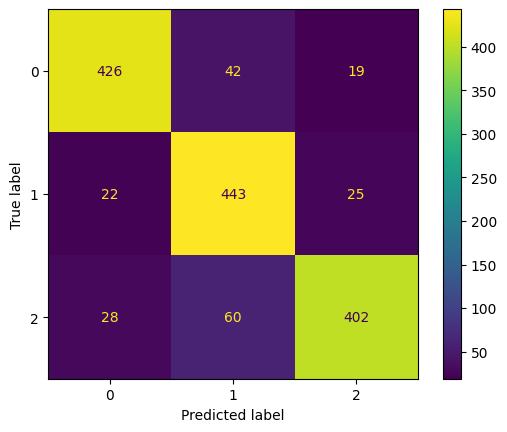

In [231]:
y_pred_prob=model.predict(x_test)
y_pred=[np.argmax(x) for x in y_pred_prob]
cm=confusion_matrix(y_test,y_pred)
ConfusionMatrixDisplay(cm).plot()

In [232]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.89      0.87      0.88       487
           1       0.81      0.90      0.86       490
           2       0.90      0.82      0.86       490

    accuracy                           0.87      1467
   macro avg       0.87      0.87      0.87      1467
weighted avg       0.87      0.87      0.87      1467



In [233]:
mfcc=conv_path_to_mfcc(df_dataset[df_dataset["label"]=="off"]["file_path"].iloc[-1])
org_shape=mfcc.shape
test_mfcc=mfcc.reshape(1,-1)
test_mfcc=scaler.transform(test_mfcc)
test_mfcc=mfcc.reshape(1,13,32,1)
test_mfcc.shape

(1, 13, 32, 1)

In [234]:
model.predict(test_mfcc)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step


array([[0., 1., 0.]], dtype=float32)